# Data Preprocessing

Data preprocessing is an essential step in the machine learning pipeline.

It involves cleaning and transforming raw data into a suitable format for model training.

The preprocessing steps performed in this notebook include:

- Handling Missing Values
- Detecting and Treating Outliers
- Encoding Categorical Variables
- Splitting the Dataset
- Feature Scaling

These steps improve data quality and enhance machine learning model performance.

### Step 1: Importing required libraries

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

### Step 2: Loading Dataset


In [13]:
dataset = pd.read_excel("../dataset/flood_dataset.xlsx")

# Step 3: Handling Missing Values

Missing values reduce the quality of the dataset and can negatively affect machine learning models.

In this step, we identify missing values and decide whether they should be removed or replaced.

In [14]:
dataset.isnull().sum()

Temp           0
Humidity       0
Cloud Cover    0
ANNUAL         0
Jan-Feb        0
Mar-May        0
Jun-Sep        0
Oct-Dec        0
avgjune        0
sub            0
flood          0
dtype: int64

In [15]:
dataset.isnull().any()

Temp           False
Humidity       False
Cloud Cover    False
ANNUAL         False
Jan-Feb        False
Mar-May        False
Jun-Sep        False
Oct-Dec        False
avgjune        False
sub            False
flood          False
dtype: bool

### Observation

- The `isnull().sum()` function shows that all columns contain **0 missing values**.
- The `isnull().any()` function confirms that no column contains missing data.
- Therefore, the dataset is complete and does not require any missing value treatment.

# Step 4: Detect and Treat Outliers

Outliers are unusually high or low values that differ significantly from the rest of the data.

These values can negatively affect machine learning model performance.

We use **box plots** to detect outliers in each numerical feature.

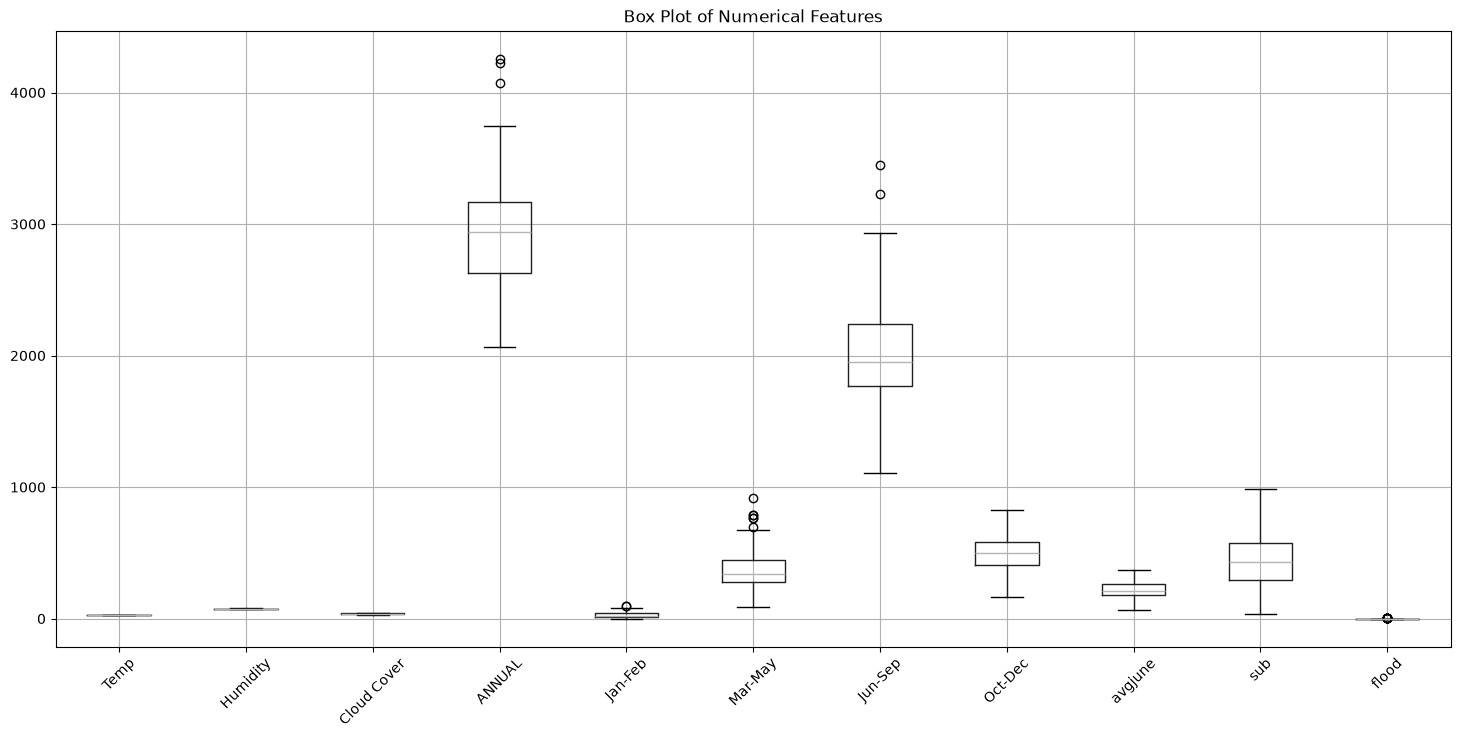

In [16]:
plt.figure(figsize=(18,8))
dataset.boxplot(rot=45)
plt.title("Box Plot of Numerical Features")
plt.show()

### Observation

The box plots indicate the presence of a few outliers in features such as **ANNUAL**, **Jan-Feb**, **Mar-May**, and **Jun-Sep**.

These values represent extreme rainfall conditions, which are natural occurrences in flood prediction datasets rather than errors.

Therefore, no outlier treatment is performed, and all observations are retained for model training.

# Step 5: Treating Outliers using IQR Capping

After identifying outliers using box plots, the Interquartile Range (IQR) method is used to calculate the lower and upper bounds.

Instead of removing outliers, the capping technique is applied.

- Values below the lower bound are replaced with the lower bound.
- Values above the upper bound are replaced with the upper bound.

This preserves the dataset size while reducing the influence of extreme values.

In [6]:
# Create a copy of the dataset
dataset_capped = dataset.copy()

# Select numerical columns except the target column
numerical_columns = dataset.columns.drop("flood")

for column in numerical_columns:
    Q1 = dataset_capped[column].quantile(0.25)
    Q3 = dataset_capped[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    dataset_capped[column] = dataset_capped[column].clip(lower=lower_bound,
                                                         upper=upper_bound)

print("Outlier capping completed successfully.")

Outlier capping completed successfully.


## Verification of Outlier Treatment

The box plot below confirms that outlier capping has reduced the influence of extreme values.

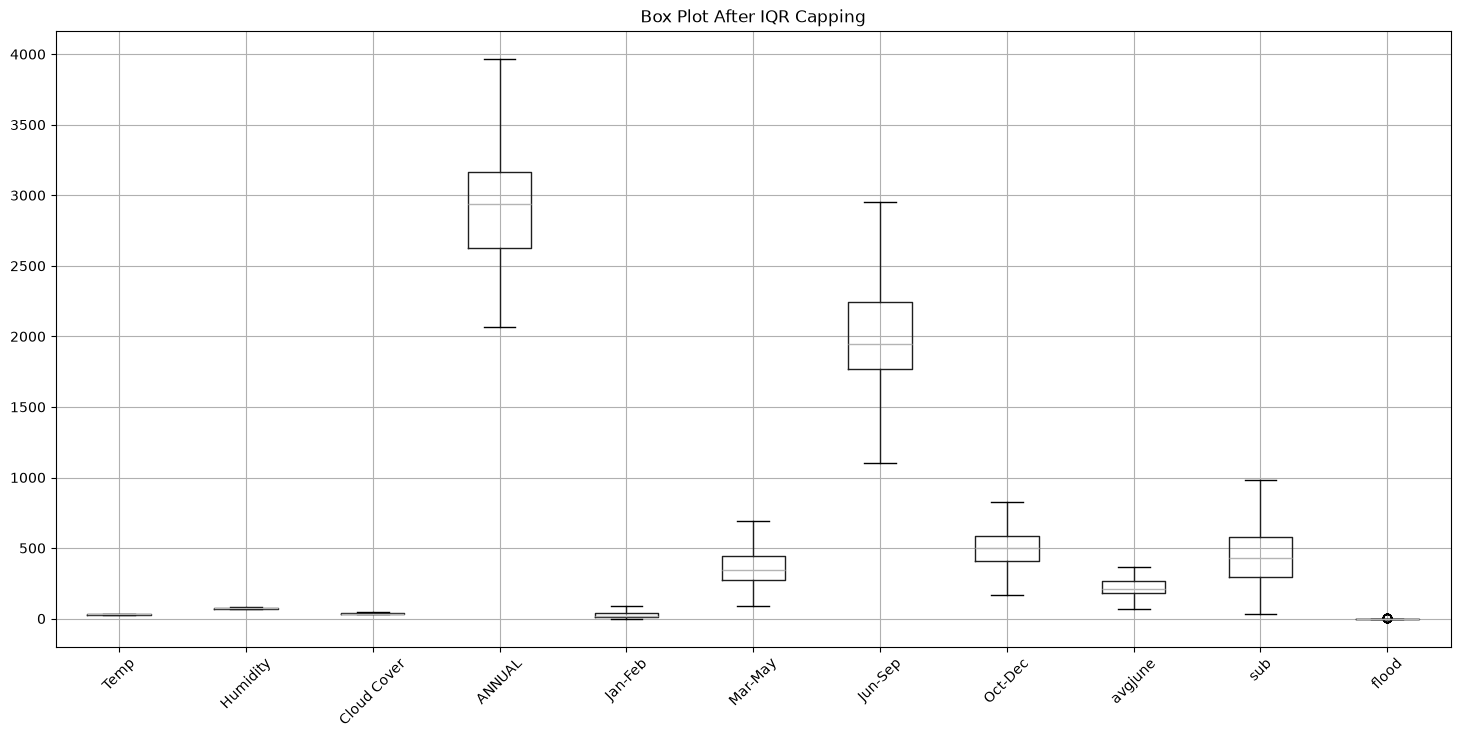

In [7]:
plt.figure(figsize=(18,8))
dataset_capped.boxplot(rot=45)
plt.title("Box Plot After IQR Capping")
plt.show()

# Step 6: Check Data Types and Encoding

Encoding converts categorical (text) data into numerical values so that machine learning algorithms can process them.

Before applying encoding, we check the data types of all columns.

In [8]:
dataset.dtypes

Temp             int64
Humidity         int64
Cloud Cover      int64
ANNUAL         float64
Jan-Feb        float64
Mar-May        float64
Jun-Sep        float64
Oct-Dec        float64
avgjune        float64
sub            float64
flood            int64
dtype: object

### Observation

- All features are already in numerical format (`int64` and `float64`).
- No categorical (text) columns are present in the dataset.
- Therefore, no encoding techniques such as Label Encoding or One-Hot Encoding are required.

In [9]:
dataset_capped.dtypes

Temp             int64
Humidity         int64
Cloud Cover      int64
ANNUAL         float64
Jan-Feb        float64
Mar-May        float64
Jun-Sep        float64
Oct-Dec        float64
avgjune        float64
sub            float64
flood            int64
dtype: object

# Step 7: Train-Test Split

Before training a machine learning model, the dataset is divided into two parts:

- **Training Set:** Used to train the machine learning model.
- **Testing Set:** Used to evaluate the model's performance on unseen data.

In this project, we use an **80:20 split**, where 80% of the data is used for training and 20% is reserved for testing.

In [10]:
from sklearn.model_selection import train_test_split

# Separate features and target variable
X = dataset_capped.drop("flood", axis=1)
y = dataset_capped["flood"]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Labels Shape:", y_train.shape)
print("Testing Labels Shape:", y_test.shape)

Training Features Shape: (92, 10)
Testing Features Shape: (23, 10)
Training Labels Shape: (92,)
Testing Labels Shape: (23,)


### Observation

- The dataset has been successfully divided into training and testing sets.
- **80% (92 records)** of the data is used for training the machine learning model.
- **20% (23 records)** of the data is reserved for testing and evaluating the model.
- Splitting the dataset before training helps evaluate the model on unseen data and reduces the risk of overfitting.

# Step 8: Feature Scaling

Feature Scaling is used to bring all numerical features to a similar range.

Machine learning algorithms such as K-Nearest Neighbors (KNN) perform better when features are scaled.

In this project, we use **StandardScaler**, which transforms the data to have:

- Mean = 0
- Standard Deviation = 1

The scaler is fitted only on the training data and then applied to both training and testing datasets.

In [11]:
from sklearn.preprocessing import StandardScaler

# Create StandardScaler object
scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data
X_test_scaled = scaler.transform(X_test)

print("Training data shape after scaling:", X_train_scaled.shape)
print("Testing data shape after scaling:", X_test_scaled.shape)

Training data shape after scaling: (92, 10)
Testing data shape after scaling: (23, 10)


### Observation

- Feature scaling has been successfully applied using **StandardScaler**.
- The scaler was fitted only on the training data to prevent data leakage.
- Both training and testing datasets have been transformed while maintaining the same dimensions.
- The scaled data is now ready for machine learning model training.